# Comprehensive Sentiment Analysis Tutorial

## Overview

This tutorial covers three major approaches to sentiment analysis:

1. **Lexicon-Based Approaches** - Rule-based methods using predefined sentiment dictionaries
2. **Machine Learning-Based Approaches** - Statistical models trained on labeled data
3. **Deep Learning-Based Approaches** - Neural networks (BERT) for context-aware sentiment analysis

### Learning Objectives

By the end of this tutorial, you will:
- Understand the evolution of sentiment analysis techniques
- Implement and compare different sentiment analysis methods
- Evaluate the strengths and weaknesses of each approach
- Apply state-of-the-art BERT models for sentiment classification

---

# 📚 Sentiment Analysis - Exam Preparation

**🎯 = Important concepts for exam**

Focus on sections marked with 🎯 - these contain key concepts you need to master.

---

## Table of Contents

1. [Data Preparation](#data-preparation)
2. [Part 1: Lexicon-Based Sentiment Analysis](#part1)
   - TextBlob
   - AFINN
   - VADER
3. [Part 2: Machine Learning-Based Sentiment Analysis](#part2)
   - Naive Bayes
   - Logistic Regression
4. [Part 3: Deep Learning with BERT](#part3)
5. [Performance Comparison](#comparison)
6. [Conclusion](#conclusion)

---
<a id='data-preparation'></a>
## 1. Data Preparation

We'll use the NLTK Movie Reviews dataset, which contains 2000 movie reviews labeled as positive or negative.

In [1]:
# Install required packages
!pip install nltk textblob afinn transformers torch scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for afinn: filename=afinn-0.1-py3-none-any.whl size=53431 sha256=1434709fdeb5045c01b6e5901e72f82024fe2ff7c86cdfaeb1e4e5cd8ff6f577
  Stored in directory: /root/.cache/pip/wheels/f9/72/27/74994e77200dae3d6aea2b546264500cee21f738c51241320b
Successfully built afinn


In [2]:
import nltk
import warnings
warnings.filterwarnings('ignore')

# Download necessary NLTK data
nltk.download('movie_reviews')
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import movie_reviews

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [3]:
# Load and explore the dataset
print('Total review count:', len(movie_reviews.fileids()))
print('Sample file IDs:', movie_reviews.fileids()[:10])
print('Categories:', movie_reviews.categories())
print('Number of negative reviews:', len(movie_reviews.fileids(categories='neg')))
print('Number of positive reviews:', len(movie_reviews.fileids(categories='pos')))

# Extract reviews and labels
fileids = movie_reviews.fileids()
reviews = [movie_reviews.raw(fileid) for fileid in fileids]
categories = [movie_reviews.categories(fileid)[0] for fileid in fileids]

print(f"\nFirst review (first 500 characters):\n{reviews[0][:500]}")
print(f"\nSentiment: {categories[0]}")

Total review count: 2000
Sample file IDs: ['neg/cv000_29416.txt', 'neg/cv001_19502.txt', 'neg/cv002_17424.txt', 'neg/cv003_12683.txt', 'neg/cv004_12641.txt', 'neg/cv005_29357.txt', 'neg/cv006_17022.txt', 'neg/cv007_4992.txt', 'neg/cv008_29326.txt', 'neg/cv009_29417.txt']
Categories: ['neg', 'pos']
Number of negative reviews: 1000
Number of positive reviews: 1000

First review (first 500 characters):
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt

Sentiment: neg


---
<a id='part1'></a>
## 2. Part 1: Lexicon-Based Sentiment Analysis

### What is Lexicon-Based Sentiment Analysis?

Lexicon-based approaches use **predefined dictionaries** where words are assigned sentiment scores. The overall sentiment is calculated by aggregating individual word scores.

**Advantages:**
- No training data required
- Fast and interpretable
- Works well for domain-specific lexicons

**Disadvantages:**
- Cannot capture context (e.g., "not good" vs "good")
- Limited to words in the lexicon
- May not generalize across domains

---

### 2.1 TextBlob

🎯 **Key Concept**: TextBlob returns TWO types of scores

TextBlob provides:
- **Polarity**: sentiment score from -1 (negative) to +1 (positive)
- **Subjectivity**: score from 0 (objective) to 1 (subjective)

💡 This is unique - TextBlob is the only method among the three that provides subjectivity scores.


In [4]:
!pip install -U textblob
!python -m textblob.download_corpora

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.


In [5]:
from textblob import TextBlob

# Test on first review
result = TextBlob(reviews[0])
print(f"Sentiment: {result.sentiment}")
print(f"Polarity: {result.sentiment.polarity}")
print(f"Subjectivity: {result.sentiment.subjectivity}")

Sentiment: Sentiment(polarity=0.06479782948532947, subjectivity=0.5188408350908352)
Polarity: 0.06479782948532947
Subjectivity: 0.5188408350908352


In [6]:
def sentiment_TextBlob(docs):
    """
    Classify sentiment using TextBlob.
    Positive if polarity > 0, else negative.
    """
    results = []
    for doc in docs:
        testimonial = TextBlob(doc)
        if testimonial.sentiment.polarity > 0:
            results.append('pos')
        else:
            results.append('neg')
    return results

In [7]:
from sklearn.metrics import accuracy_score

# Evaluate TextBlob
textblob_predictions = sentiment_TextBlob(reviews)
textblob_accuracy = accuracy_score(categories, textblob_predictions)
print(f'TextBlob Accuracy: {textblob_accuracy:.3f}')

TextBlob Accuracy: 0.600


### 2.2 AFINN

🎯 **Key Concept**: AFINN scoring system

AFINN characteristics:
- Uses **integer ratings between -5 and +5**
- Includes **emoticon support** (e.g., :) = +2, :( = -2)
- Pre-built dictionary of rated words

💡 Remember the range: -5 to +5 (integers only)


In [8]:
!pip install afinn

In [9]:
from afinn import Afinn

def sentiment_Afinn(docs):
    """
    Classify sentiment using AFINN.
    Positive if score > 0, else negative.
    """
    afn = Afinn(emoticons=True)
    results = []
    for doc in docs:
        if afn.score(doc) > 0:
            results.append('pos')
        else:
            results.append('neg')
    return results

# Evaluate AFINN
afinn_predictions = sentiment_Afinn(reviews)
afinn_accuracy = accuracy_score(categories, afinn_predictions)
print(f'AFINN Accuracy: {afinn_accuracy:.3f}')

AFINN Accuracy: 0.664


### 2.3 VADER (Valence Aware Dictionary and sEntiment Reasoner)

🎯 **Key Concept**: VADER for social media

VADER is **specifically designed for social media text**:

**Handles context**:
- **Punctuation**: "good" vs "good!!!" (more positive)
- **Capitalization**: "amazing" vs "AMAZING" (stronger emotion)
- **Negation**: "not good" (reverses sentiment)
- **Degree modifiers**: "very good" (intensifies)

**Returns 4 scores**:
- `pos`: positive score
- `neg`: negative score
- `neu`: neutral score
- `compound`: overall score from -1 to +1

💡 The compound score is most commonly used for classification


In [10]:
# 🎯 Important Code Pattern: VADER Implementation
# Study this pattern carefully - you need to understand how to:
# 1. Initialize the VADER analyzer
# 2. Get sentiment scores for text
# 3. Use the compound score for classification

from nltk.sentiment.vader import SentimentIntensityAnalyzer

def sentiment_vader(docs):
    """
    Classify sentiment using VADER.
    Uses compound score: positive if > 0, else negative.
    """
    # 🎯 Step 1: Initialize the analyzer
    analyser = SentimentIntensityAnalyzer()

    results = []
    for doc in docs:
        # 🎯 Step 2: Get polarity scores (returns a dictionary)
        score = analyser.polarity_scores(doc)

        # 🎯 Step 3: Use 'compound' key for classification
        # compound score is the overall sentiment
        if score['compound'] > 0:
            results.append('pos')
        else:
            results.append('neg')

    return results

# Test the function
vader_predictions = sentiment_vader(reviews)
vader_acc = accuracy_score(categories, vader_predictions)
print(f'VADER Accuracy: {vader_acc:.3f}')

# 💡 Remember:
# - SentimentIntensityAnalyzer() to create analyzer
# - polarity_scores(text) to get scores
# - score['compound'] for the overall sentiment value


VADER Accuracy: 0.635


### Summary: Lexicon-Based Methods

🎯 **Key Concept**: Understanding lexicon-based approaches

| Method | Scores | Range | Special Features |
|--------|--------|-------|------------------|
| TextBlob | Polarity + Subjectivity | -1 to +1 | Two types of scores |
| AFINN | Single score | **-5 to +5** (integers) | **Emoticons** |
| VADER | 4 scores | -1 to +1 | **Social media optimized** |

💡 **Critical Understanding**: All three methods use **pre-built dictionaries**
- Words are already rated by researchers
- No training data needed
- No machine learning required
- This is what makes them "lexicon-based"



Lexicon-Based Methods Performance:
  Method  Accuracy
TextBlob     0.600
   AFINN     0.664
   VADER     0.635


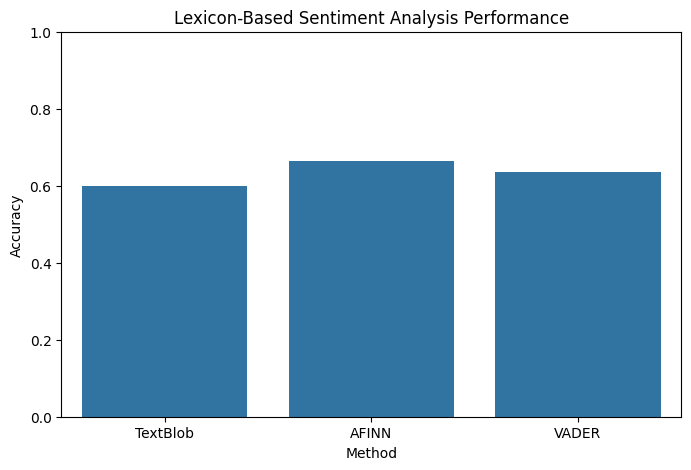

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

lexicon_results = pd.DataFrame({
    'Method': ['TextBlob', 'AFINN', 'VADER'],
    'Accuracy': [textblob_accuracy, afinn_accuracy, vader_acc]
})

print("\nLexicon-Based Methods Performance:")
print(lexicon_results.to_string(index=False))

# Visualize
plt.figure(figsize=(8, 5))
sns.barplot(data=lexicon_results, x='Method', y='Accuracy')
plt.title('Lexicon-Based Sentiment Analysis Performance')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.show()

---
<a id='part2'></a>
## 3. Part 2: Machine Learning-Based Sentiment Analysis

### What is Machine Learning-Based Sentiment Analysis?

ML-based approaches **learn patterns from labeled training data** rather than relying on predefined rules.

**Key Steps:**
1. **Feature Extraction**: Convert text to numerical features (e.g., TF-IDF)
2. **Model Training**: Train a classifier on labeled data
3. **Prediction**: Classify new text based on learned patterns

**Advantages:**
- Can learn domain-specific patterns
- Better handles context and nuances
- Adaptable to different domains with retraining

**Disadvantages:**
- Requires labeled training data
- More computationally expensive than lexicon-based
- Performance depends on training data quality

---

### 3.1 Data Splitting

In [13]:
from sklearn.model_selection import train_test_split

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    reviews, categories, test_size=0.2, random_state=42
)

print(f'Training set size: {len(X_train)}')
print(f'Test set size: {len(X_test)}')

Training set size: 1600
Test set size: 400


### 3.2 Naive Bayes Classifier

Naive Bayes is a probabilistic classifier based on Bayes' theorem. It assumes features are independent ("naive" assumption).

**Formula:**
$$P(\text{class} | \text{features}) = \frac{P(\text{features} | \text{class}) \cdot P(\text{class})}{P(\text{features})}$$

It's particularly effective for text classification.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'Training set shape: {X_train_tfidf.shape}')
print(f'Test set shape: {X_test_tfidf.shape}')

# Train Naive Bayes
nb_clf = MultinomialNB(alpha=0.01)
nb_clf.fit(X_train_tfidf, y_train)

# Evaluate
nb_train_score = nb_clf.score(X_train_tfidf, y_train)
nb_test_score = nb_clf.score(X_test_tfidf, y_test)

print(f'\nNaive Bayes Training Accuracy: {nb_train_score:.3f}')
print(f'Naive Bayes Test Accuracy: {nb_test_score:.3f}')

Training set shape: (1600, 5000)
Test set shape: (400, 5000)

Naive Bayes Training Accuracy: 0.933
Naive Bayes Test Accuracy: 0.802


### 3.3 Logistic Regression

Logistic Regression is a linear model for binary classification. Despite its name, it's used for classification, not regression.

**Formula:**
$$P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + ... + \beta_n x_n)}}$$

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train Logistic Regression
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_train_tfidf, y_train)

# Evaluate
lr_train_score = lr_clf.score(X_train_tfidf, y_train)
lr_test_score = lr_clf.score(X_test_tfidf, y_test)

print(f'Logistic Regression Training Accuracy: {lr_train_score:.3f}')
print(f'Logistic Regression Test Accuracy: {lr_test_score:.3f}')

Logistic Regression Training Accuracy: 0.966
Logistic Regression Test Accuracy: 0.828


In [16]:
# Detailed evaluation
y_pred_lr = lr_clf.predict(X_test_tfidf)
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))


Classification Report (Logistic Regression):
              precision    recall  f1-score   support

         neg       0.82      0.83      0.83       199
         pos       0.83      0.83      0.83       201

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



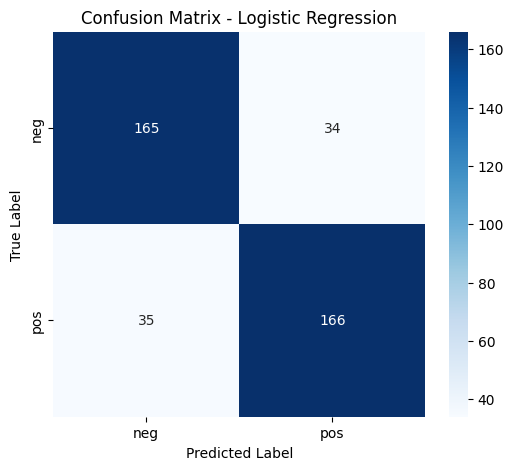

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['neg', 'pos'], yticklabels=['neg', 'pos'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Summary: Machine Learning Results


Machine Learning Methods Performance:
             Method  Train Accuracy  Test Accuracy
        Naive Bayes        0.933125         0.8025
Logistic Regression        0.966250         0.8275


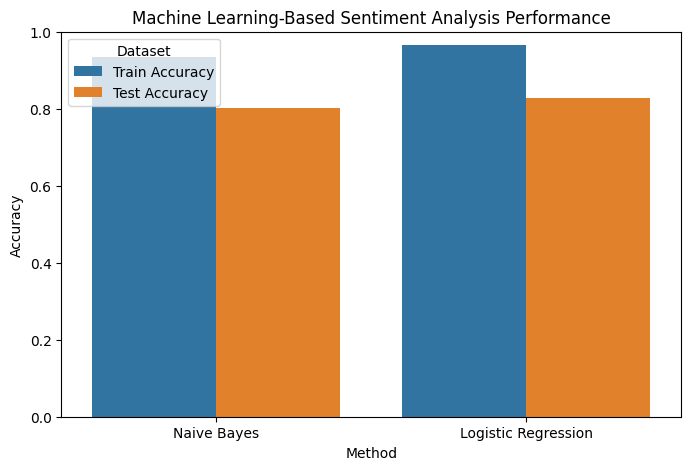

In [18]:
ml_results = pd.DataFrame({
    'Method': ['Naive Bayes', 'Logistic Regression'],
    'Train Accuracy': [nb_train_score, lr_train_score],
    'Test Accuracy': [nb_test_score, lr_test_score]
})

print("\nMachine Learning Methods Performance:")
print(ml_results.to_string(index=False))

# Visualize
ml_results_melted = ml_results.melt(id_vars='Method', var_name='Set', value_name='Accuracy')
plt.figure(figsize=(8, 5))
sns.barplot(data=ml_results_melted, x='Method', y='Accuracy', hue='Set')
plt.title('Machine Learning-Based Sentiment Analysis Performance')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(title='Dataset')
plt.show()